In [1]:
%ls

 El volumen de la unidad C no tiene etiqueta.
 El número de serie del volumen es: EA01-00BA

 Directorio de C:\Users\gabri\anaconda_projects\f98897e2-f09d-4c09-9df6-8c3c248e307d

07/07/2026  02:33 p. m.    <DIR>          .
07/07/2026  09:38 a. m.    <DIR>          ..
06/07/2026  10:58 p. m.    <DIR>          .ipynb_checkpoints
06/07/2026  10:54 p. m.           573,440 2022_06_27_512x140_redMOT_shelving_(p=tof,exposure_time_side,number_of_images_side,exposure_time_vertical,number_of_images_vertical)#0.0_0.005_4_0.03_4_140957_1.bin
06/07/2026  10:54 p. m.           573,440 2022_06_27_512x140_redMOT_shelving_(p=tof,exposure_time_side,number_of_images_side,exposure_time_vertical,number_of_images_vertical)#0.0_0.005_4_0.03_4_140957_2.bin
06/07/2026  10:54 p. m.           573,440 2022_06_27_512x140_redMOT_shelving_(p=tof,exposure_time_side,number_of_images_side,exposure_time_vertical,number_of_images_vertical)#0.0_0.005_4_0.03_4_140957_3.bin
07/07/2026  02:33 p. m.           562,560 RAI.ipyn

In [11]:
import os

os.listdir()

['.ipynb_checkpoints',
 '2022_06_27_512x140_redMOT_shelving_(p=tof,exposure_time_side,number_of_images_side,exposure_time_vertical,number_of_images_vertical)#0.0_0.005_4_0.03_4_140957_1.bin',
 '2022_06_27_512x140_redMOT_shelving_(p=tof,exposure_time_side,number_of_images_side,exposure_time_vertical,number_of_images_vertical)#0.0_0.005_4_0.03_4_140957_2.bin',
 '2022_06_27_512x140_redMOT_shelving_(p=tof,exposure_time_side,number_of_images_side,exposure_time_vertical,number_of_images_vertical)#0.0_0.005_4_0.03_4_140957_3.bin',
 'RAI-Copy1.ipynb',
 'RAI-Copy2.ipynb',
 'RAI.ipynb',
 'README.txt']

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [116]:
#Image Size
height=140
width=512

In [117]:
#Carpeta de archivos
atom = np.fromfile ( "2022_06_27_512x140_redMOT_shelving_(p=tof,exposure_time_side,number_of_images_side,exposure_time_vertical,number_of_images_vertical)#0.0_0.005_4_0.03_4_140957_1.bin",
                     dtype = np.float64 )
reference = np.fromfile( "2022_06_27_512x140_redMOT_shelving_(p=tof,exposure_time_side,number_of_images_side,exposure_time_vertical,number_of_images_vertical)#0.0_0.005_4_0.03_4_140957_2.bin", dtype=np.float64 )
dark = np.fromfile ("2022_06_27_512x140_redMOT_shelving_(p=tof,exposure_time_side,number_of_images_side,exposure_time_vertical,number_of_images_vertical)#0.0_0.005_4_0.03_4_140957_3.bin", dtype=np.float64 )
       

In [118]:
print(atom.shape)
print(reference.shape)
print(dark.shape)

(71680,)
(71680,)
(71680,)


In [119]:
#Reshape
atom=atom.reshape((height, width))
reference=reference.reshape((height, width))
dark=dark.reshape((height, width))

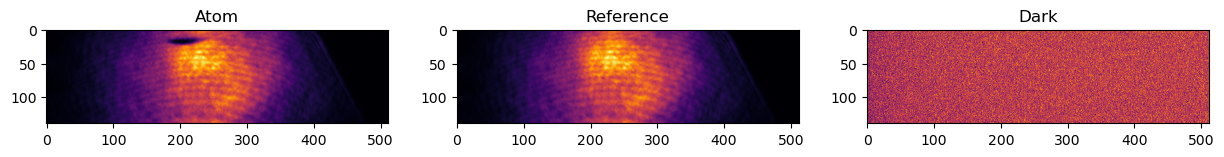

In [120]:
#Imágenes Originales
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.imshow(atom,cmap="inferno")
plt.title("Atom")

plt.subplot(1,3,2)
plt.imshow(reference, cmap="inferno")
plt.title("Reference")

plt.subplot(1,3,3)
plt.imshow(dark, cmap="inferno")
plt.title("Dark")

plt.show()

In [121]:
#Quitar fondo
#Corr de correction
atom_corr=atom-dark
reference_corr=reference-dark


In [122]:
#Evitar errores matemáticos
epsilon=1e-10
#Comparar valor
atom_corr=np.clip(atom_corr,epsilon, None)
reference_corr=np.clip(reference_corr,epsilon, None)

In [123]:
#Optical Density, muestra cuánta luz absorbieron los átomos
OD=np.log(reference_corr/atom_corr)
OD_gaussian = gaussian_filter(OD, sigma=2)

In [124]:
#Límite
OD=np.clip(OD,0,5)

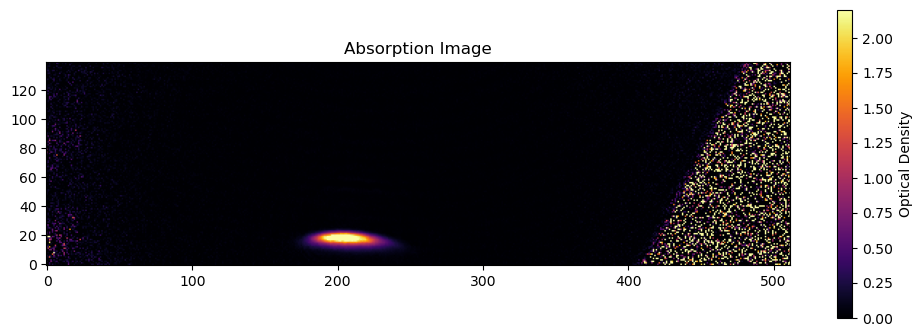

In [125]:
#Absorption Image
plt.figure(figsize=(12,4))
#Lower, cambiar la dirección de Y
plt.imshow(OD,cmap="inferno",origin="lower", vmin=0, vmax=2.2)
plt.colorbar(label="Optical Density")
plt.title("Absorption Image")
plt.show()

In [126]:
#Suavizar Imágen, ayuda a que el ruido no se confunda con la nube
kernel_size=9
kernel=np.ones(kernel_size)/kernel_size

#Suavizar horizontalmente
OD_smooth= np.apply_along_axis(
    lambda row: np.convolve(row, kernel, mode="same"),
    axis=1,
    arr=OD )
#Suavizar Verticalmente
OD_smooth= np.apply_along_axis (
    lambda col: np.convolve(col, kernel, mode="same"),
    axis=0,
    arr=OD_smooth )
#Punto máximo
#np.argmax, valor máximo como índice plano
#np.unravel_index, lo convierte en coordenadas y, x.
y_max, x_max = np.unravel_index(np.argmax(OD_smooth), OD_smooth.shape)

print("Coordenada máxima:")
print("y =", y_max)
print("x =", x_max)

Coordenada máxima:
y = 18
x = 204


In [127]:
#Región de interés, ROI
#Max y Min evita salir de los límites de la imagen.
#50 pixeles arriba y abajo del máximo
y1=max(y_max-50,0)
y2=min(y_max+51, OD.shape[1])
#30 pixeles a la izquiera y derecha.
x1=max(x_max-30,0)
x2=min(x_max+31, OD.shape[1])

roi=OD_gaussian[y1:y2,x1:x2]

print("ROI shape:", roi.shape)
print("y range:", y1, y2)
print("x range:", x1, x2)


ROI shape: (69, 61)
y range: 0 69
x range: 174 235


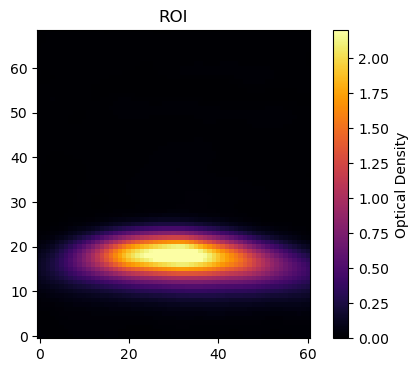

In [128]:
roi_gaussian=OD_gaussian[y1:y2, x1:x2]

#Imagen ROI
plt.figure(figsize=(6,4))
plt.imshow(roi,cmap="inferno",origin="lower",vmin=0, vmax=2.2)
plt.colorbar(label="Optical Density")
plt.title("ROI")
plt.show()

In [129]:
#Camera pixel
pixel_camera=16e-6
#Magnification
magnification=2
#Calcula tamaño real de un pixel en la imagen de los átomos
pixel_atoms=pixel_camera/magnification
#Área de un pixel en metros cuadrados
pixel_area=pixel_atoms**2
print(pixel_area)

6.4e-11


In [130]:
#Imaging WaveLenght
wavelength=460.8e-9
#Resonant Cross Section
sigma=3*wavelength**2/(2*np.pi)
print(sigma)

1.0138327756657282e-13


In [131]:
#Suma de todo los valores de OD dentro de ROI
OD_sum=np.sum(roi)
print("OD sum",OD_sum)
#Número de átomos
N_atoms=OD_sum*pixel_area/sigma
print("Estimated number of atoms={:.3e}".format(N_atoms))

OD sum 812.2808255782927
Estimated number of atoms=5.128e+05
